目的
* **ImageNetで学習済みのVGG16を「特徴抽出器」として固定して使い、その出力を入力とする小さな全結合(FC)分類器だけを新たに学習する。** 少量データ(訓練2000枚・検証800枚)でも、短時間で高精度な2クラス分類が可能になる。
(所要時間約20分間)
---
Objective
* **Use VGG16, pretrained on ImageNet, as a fixed feature extractor, and train only a small fully connected (FC) classifier on top of its outputs**. This enables fast, high-accuracy binary classification even with a small dataset (2,000 training images and 800 validation images).(Approximate duration: 20 minutes)

準備
* GPUを用いて処理を行うために、上部のメニューバーの「ランタイム」→「ランタイムのタイプを変更」からハードウェアアクセラレータをGPUにしてください。
---
Preparation
* To use GPU for processing, go to the top menu bar and select “Runtime” → “Change runtime type”, then set the hardware accelerator to GPU.

流れ
1. VGG16(全結合層なし)に画像を通して特徴を取り出し、.npyファイルに保存する
2. 保存した特徴を読み込み、自作の全結合ネットワークで「ネコ/イヌ」を学習する
3. 学習の推移(精度・損失)をグラフで確認する
---
Workflow
1. Pass the images through VGG16 (without the fully connected layers) to extract features, and save the extracted features as .npy files.
2. Load the saved features and train a custom fully connected neural network to classify the images as cats or dogs.
3. Visualize the training progress by plotting the accuracy and loss over the course of training.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Deep learning/3data/

Mounted at /content/drive
/content/drive/MyDrive/Deep learning/3data


VGG16を利用した転移学習のためのプログラムを作成

プログラムの構造
* 訓練データを**FC層を取り除いた**VGG16モデル(ImageNetで学習した重みをもつ画像分類のモデル)に入力し、出力結果をバリナリデータとして保存
* これを再度読み込んで、**自前のFC層を備えたネットワーク**で学習
* 最終的に1個のニューロンに出力
* テストデータについても同じ処理
---
Create a program for transfer learning using VGG16

Program Structure
* Input training data into a VGG16 model (with ImageNet-pretrained weights) with the **fully connected layers removed**, and save the output as binary data.
* Reload this and train it using **a network with your own fully connected (FC) layers**.
* Finally outputs to a single neuron.
* Apply the same processing to the test data as well.

npy file: https://note.nkmk.me/python-numpy-load-save-savez-npy-npz/
* NumPy配列ndarrayをNumPy独自フォーマットのバイナリファイル（npy, npz）で保存する場合、データ型dtypeや形状shapeなどの情報がそのまま保存される。
* When saving a NumPy array (ndarray) in NumPy’s proprietary binary formats (npy or npz), information such as the data type (dtype) and shape (shape) is preserved as is.

npy file: https://qiita.com/ShozF/items/ef3629064f930e85c20f
* ヘッダ部の情報に基づいて配列要素がバイト列として隙間なく格納されています。
* The array elements are stored consecutively as byte sequences based on the information in the header.

os.path.join()
* 引数に渡した2つの文字列を結合し、1つのパスにすることが出来ます。
* You can concatenate the two strings passed as arguments to form a single path.

In [ ]:
from keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Input
import numpy as np
import os

num_train = 2000              # 訓練データの画像数/Number of images in training data
num_validation = 800          # テストデータの画像数/Number of images in test data
img_h, img_w = 150, 150       # 画像のサイズ/Image size
channels = 3                  # チャンネル数/Number of channels
batch_size = 32               # ミニバッチのサイズ/mini-batch size
train_data_dir = '/content/drive/MyDrive/Deep learning/3data/train' # 訓練データのフォルダ/training data folder
validation_data_dir = '/content/drive/MyDrive/Deep learning/3data/validation' # テストデータのフォルダ/test data folder
result_dir = '/content/drive/MyDrive/Deep learning/3data/results'        # VGG16の出力結果を保存するフォルダ/Folder to save the output results of VGG16

# resultsフォルダが存在しなければ作成/Create the 'results' folder if it does not exist
if not os.path.exists(result_dir):
    os.mkdir(result_dir)

def save_VGG16_outputs():
    '''
    VGG16にDog vs Catの訓練データ、テストデータを入力し、
    出力結果をnpyファイルに保存する

　　'''
    # VGG16モデルと学習済み重みを読み込む/Load the VGG16 model and its pre-trained weights
    model = VGG16(
        include_top=False,            # 全結合層は層（FC）は読み込まない/The fully connected (FC) layer is not loaded
        weights='imagenet',           # ImageNetで学習した重みを利用/Use weights pretrained on ImageNet
        input_shape=(img_h, img_w, channels) # 入力データの形状/Shape of input data
    )
    # サマリを表示/Display summary
    model.summary()

    # データを読み込むジェネレータを生成/Generate a generator that reads data
    datagen = ImageDataGenerator(rescale=1.0 / 255)
    # Dog vs Catの訓練データを生成するジェネレータ/Generator to create training data for Dog vs Cat
    train_generator = datagen.flow_from_directory(
        train_data_dir,               # 訓練データのフォルダ/training data folder
        target_size=(img_w, img_h),   # 画像をリサイズ/Resize the image
        batch_size=batch_size,        # ミニバッチのサイズ/mini-batch size
        class_mode=None,              # 出力層は存在しないのでclass_modeはNone/Since there is no output layer, class_mode is set to None
        shuffle=False)                # データをシャッフルしない/Do not shuffle the data
    # 訓練データの正解ラベルを出力/Output the correct labels of the training data
    print('train-label:',train_generator.class_indices)
    # 訓練データをVGG16モデルに入力し、その出力をファイルに保存/Input the training data into the VGG16 model and save its output to a file
    vgg16_train = model.predict(
        train_generator,              # ジェネレータ/generator
        verbose=1                     # 進捗状況を出力/Output the progress
    )
    # 訓練データの出力を保存/Save the training output
    np.save(os.path.join(result_dir, 'vgg16_train.npy'),
            vgg16_train)

    # Dog vs Catのテストデータを生成するジェネレータ/Generator for creating Dog vs Cat test data
    validation_generator = datagen.flow_from_directory(
        validation_data_dir,          # 訓練データのフォルダ/training data folder
        target_size=(img_w, img_h),   # 画像をリサイズ/Resize the image
        batch_size=batch_size,        # ミニバッチのサイズ/mini-batch size
        class_mode=None,              # 出力層は存在しないのでclass_modeはNone/Since there is no output layer, class_mode is set to None
        shuffle=False)                # データをシャッフルしない/Do not shuffle the data
    # テストデータの正解ラベルを出力/Output the correct labels of the test data
    print('test-label:',validation_generator.class_indices) #class_indicesでラベルと番号を取得/Obtain labels and their corresponding indices using class_indices
    # テストデータをVGG16モデルに入力する/Input the test data into the VGG16 model
    vgg16_test = model.predict(
        validation_generator,         # ジェネレータ/generator
        verbose=1                     # 進捗状況を出力/Output the progress
    )
    # テストデータの出力を保存/Save the test data output
    np.save(os.path.join(result_dir, 'vgg16_test.npy'),
            vgg16_test)

* VGG16に入力して結果を保存
* Input into VGG16 and save the results

In [ ]:
# VGG16に入力して結果を保存/Input into VGG16 and save the results
save_VGG16_outputs()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

Found 2000 images belonging to 2 classes.
train-label: {'cats': 0, 'dogs': 1}
63/63 ━━━━━━━━━━━━━━━━━━━━ 388s 6s/step
Found 800 images belonging to 2 classes.
test-label: {'cats': 0, 'dogs': 1}
25/25 ━━━━━━━━━━━━━━━━━━━━ 148s 6s/step


VGG16の出力をFCネットワークで学習
* 独自のFC層を構築
* VGG16の出力から学習
---
Train a fully connected network using the output of VGG16
* Build a custom fully connected (FC) layer
* Learning from the outputs of VGG16

出力層：Dense(1, activation=’sigmoid’)
* Dense()の引数にはDense(ユニット数, activation='活性化関数'）を指定
* 二値分類が目的であれば、必要な出力は1つ。この出力は、"ネコ "を値0、"イヌ "を値1として表すため、0か1のどちらかになります。
* https://machinelearningmastery.com/how-to-develop-a-convolutional-neural-network-to-classify-photos-of-dogs-and-cats/
---
output layer：Dense(1, activation=’sigmoid’)
* For the arguments of Dense(), specify them as Dense(number of units, activation='activation function').
* If the goal is binary classification, only one output is needed. This output will be either 0 or 1, representing "cat" as 0 and "dog" as 1.
* https://machinelearningmastery.com/how-to-develop-a-convolutional-neural-network-to-classify-photos-of-dogs-and-cats/

In [ ]:
import os
import numpy as np
from keras.models import Sequential
from keras import optimizers
from keras.layers import Activation, Dropout, Flatten, Dense

def train_FClayer():
    '''
    VGG16の出力を入力し、FCネットワークで学習する

    '''
    # 訓練データのVGG16からの出力を読み込む/Load the outputs from VGG16 for the training data
    train_data = np.load(
        os.path.join(result_dir, 'vgg16_train.npy'))
    # VGG16の訓練データの形状を出力/Output the shape of the training data for VGG16
    print(train_data.shape)
    # 正解ラベルの作成 最初の1000枚が0(cat)次の1000枚が1(dog)/Create label array: the first 1000 are 0 (cat), the next 1000 are 1 (dog)
    train_labels = np.array(
        [0] * int(num_train / 2) + [1] * int(num_train / 2)
    )

    # テストデータのVGG16からの出力を読み込む/Load the output from VGG16 for the test data
    validation_data = np.load(
        os.path.join(result_dir, 'vgg16_test.npy'))
    # VGG16のテストデータの形状を出力/Print the shape of the test data for VGG16
    print(validation_data.shape)
    # 正解ラベルを作成/Create ground truth labels
    # ネコが0、イヌが1/Cat=0, Dog=1
    # 最初の400枚(cat)に0次の400枚(dog)に1を割り当てる/Assign 0 to the first 400 images (cats) and 1 to the next 400 images (dogs)
    validation_labels = np.array(
        [0] * int(num_validation / 2) + [1] * int(num_validation / 2)
    )

    # FCネットワークの作成/Create a Fully Connected Neural Network
    model = Sequential()
    # Flatten　全結合層への入力を4階テンソルから2階テンソルに変換する/Reshape a 4D tensor into a 2D tensor for input to a fully connected layer
    model.add(Flatten(input_shape=train_data.shape[1:]))
    # 全結合層/Fully Connected Layer
    model.add(Dense(256,                   # ニューロン数は256/Number of neurons: 256
                    activation='relu'))    # 活性化関数はReLU/The activation function is ReLU
    model.add(Dropout(0.5))                # ドロップアウト50％/Dropout 50%
    # 出力層/output layer
    model.add(Dense(1,                     # ニューロン数は1/Number of neurons: 1
                    activation='sigmoid')) # 活性化関数はsigmoid/The activation function is sigmoid

    # モデルのコンパイル/Compile the model
    model.compile(
        loss='binary_crossentropy',        # バイナリ用の交差エントロピー誤差/binary cross-entropy loss
        metrics=['accuracy'],              # 学習評価として正解率を指定/Specify accuracy as the evaluation metric for training
        # 確率的勾配降下法で最適化 学習率0.0001/Using SGD with a learning rate of 0.0001
        # 慣性項(Momentum)を0.9にして前回の更新量に0.9倍して加算することでパラメータの更新を慣性的なものにする
        # By setting the momentum term to 0.9, the previous update is multiplied by 0.9 and added, making the parameter updates more inertial
        optimizer=optimizers.SGD(learning_rate=1e-4, momentum=0.9),
    )

    # 学習の実行/Training Execution
    epoch = 60                             # 学習回数/number of epochs
    batch_size = 32                        # ミニバッチのサイズ/mini-batch size
    history = model.fit(train_data,        # 訓練データ/training data
                        train_labels,      # 訓練データの正解ラベル/training data label
                        epochs=epoch,      # 学習回数/number of epochs
                        batch_size=batch_size,
                        verbose=1,
                        # テストデータと正解ラベル/test data and training data label
                        validation_data=(validation_data,
                                         validation_labels)
                        )

    # 学習結果の保存/Saving training results
    with open('/content/drive/MyDrive/Deep learning/3data/results/model.json', 'w') as json_file:
        json_file.write(model.to_json())
    model.save_weights('/content/drive/MyDrive/Deep learning/3data/results/weights.weights.h5')

    # historyを返す/Return the history
    return history

In [ ]:
# VGG16の出力をFCネットワークで学習/Train a fully connected network using the feature outputs from VGG16
history = train_FClayer()

(2000, 4, 4, 512)
(800, 4, 4, 512)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5430 - loss: 0.7399 - val_accuracy: 0.7450 - val_loss: 0.5827
Epoch 2/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6945 - loss: 0.5835 - val_accuracy: 0.8275 - val_loss: 0.5103
Epoch 3/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7425 - loss: 0.5264 - val_accuracy: 0.8238 - val_loss: 0.4721
Epoch 4/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7800 - loss: 0.4873 - val_accuracy: 0.8550 - val_loss: 0.4411
Epoch 5/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7895 - loss: 0.4624 - val_accuracy: 0.8612 - val_loss: 0.4143
Epoch 6/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8090 - loss: 0.4405 - val_accuracy: 0.8662 - val_loss: 0.3962
Epoch 7/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8095 - loss: 0.4267 - val_accuracy: 0.8662 - val_loss: 0.3842
Epoch 8/60
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8215 - loss: 0.4101 - val_accuracy: 0.8813 - val_loss

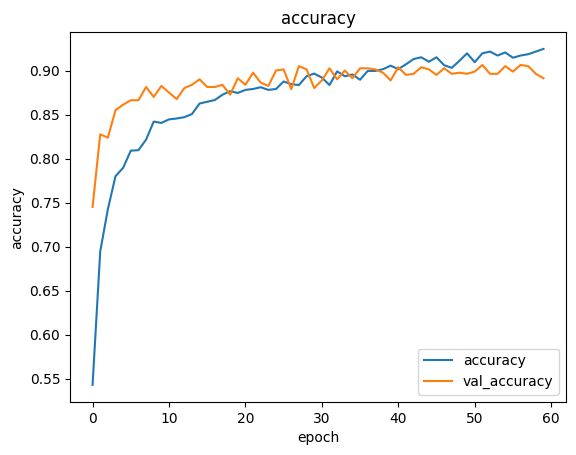

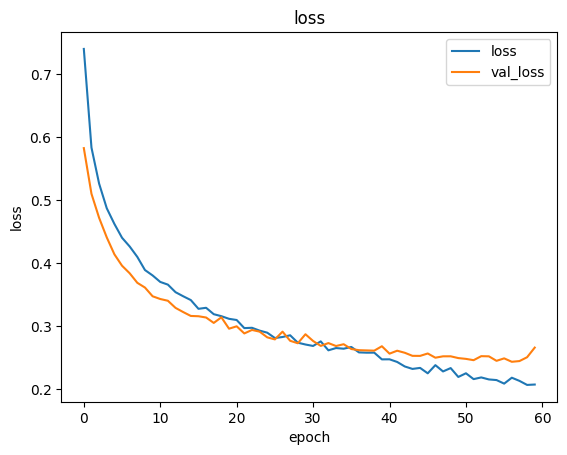

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

def plot_acc_loss(history):
    # 精度の推移をプロット/Plot accuracy per epoch
    plt.plot(history.history['accuracy'],"-",label="accuracy")
    plt.plot(history.history['val_accuracy'],"-",label="val_accuracy")
    plt.title('accuracy')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.legend(loc="lower right")
    plt.show()

    # 損失の推移をプロット/Plot the training loss over epochs
    plt.plot(history.history['loss'],"-",label="loss",)
    plt.plot(history.history['val_loss'],"-",label="val_loss")
    plt.title('loss')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(loc='upper right')
    plt.show()

# 損失と精度をグラフに出力/Visualize the loss and accuracy in a graph
plot_acc_loss(history)